# Full-match video: annotation + pressure animation + pass options

**Standalone**: this notebook does not need the analysis notebook (`football_buildup_pressure_ordered_v3`) to be open or run in this session. It reads only files:

- `buildup_output/pressure_stats_input/` (`frames`, `positions`, `roster`, `meta.json`), the export of section 16 of the analysis notebook: pressers per frame, the corrected ball carrier, player positions for the pass lanes, numbers and inferred positions;
- the original `player_frame_table_named.parquet` and `ball_frame_table_named.parquet` (pixel boxes, feet, ball pixels) and the match video.

**What the video shows** (one continuous video of the whole first half): the v5 player tags (number + position), the carrier marker, the ball, the pressing ring around the carrier (white = nobody presses, orange = 1 presser, red = 2+), and the pass lanes from the carrier (open / contested / blocked) with a small legend.
**Not drawn:** top bar, timeline, status chip, outcome banners ("BALL LOST", "ENTERED THE FINAL THIRD"), final-third marks, defensive line, nearest-opponent lines, minimap. Nothing is cut around build-ups.

| # | Section |
|---|---|
| 1 | Settings and data |
| 2 | Annotation (ball marker, v5 tags) |
| 3 | Camera, pass options, pressing ring, legend |
| 4 | Frame stream + preview of single frames |
| 5 | Render (chunked, resumable) and join |

Run 1 to 4, check the preview, then try `RANGE_MIN = (10.0, 10.5)` in cell 1 before rendering the whole half (`RANGE_MIN = None`).

## 1. Settings and data

In [1]:
# ================================================================== 1. Settings and data (this notebook is standalone: it needs only files, not the analysis notebook)
# Reads:  the export of section 16 of the analysis notebook (pressure_stats_input/: frames, positions, roster, meta),
#         the original player / ball tables (pixel boxes, feet, ball pixels) and the match video.
# Writes: one continuous video of the whole first half to OUT_DIR / full_match / ...  (annotation + pressure animation + pass options, no top bar, no outcome labels).
import json, time, os, shutil, subprocess
import numpy as np
import pandas as pd
from pathlib import Path
import cv2
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

# ------------------------------------------------------------------ where things are
BASE_DIR = "C:/Users/user/Desktop/Football_cv_project/football-pipeline (1)/project/barca_atletico_first_half"
VIDEO_PATH = BASE_DIR + "/clip.mkv"
PLAYER_PATH = BASE_DIR + "/new_cache/player_frame_table_named.parquet"
BALL_PATH = BASE_DIR + "/new_cache/ball_frame_table_named.parquet"
NOTEBOOK_DIR = Path("C:/Users/user/Desktop/Football_cv_project/football-pipeline (1)/project/new/press")
if not NOTEBOOK_DIR.exists():
    NOTEBOOK_DIR = Path.cwd()
OUT_DIR = NOTEBOOK_DIR / "buildup_output"
INPUT_DIR = OUT_DIR / "pressure_stats_input"                 # written by section 16 of the analysis notebook
FULL_DIR = OUT_DIR / "full_match"; FULL_DIR.mkdir(parents=True, exist_ok=True)     # parts and the joined video go here (new folder name = a fresh render)
FULL_NAME = "full_match_first_half"
FRAME_OFFSET = 0             # video frame = frame_idx + FRAME_OFFSET (change it if the drawings are shifted in time)

# ------------------------------------------------------------------ what is drawn
MATCH_LAYERS = dict(press_radius=True, pass_lanes=True)      # the two ground layers; everything else (top bar, outcome banners, final-third marks, ...) does not exist here
RING_WHEN_NOT_PRESSED = True # white ring around the carrier when nobody presses (as in the clips); False = the ring only appears while he is pressed
DASHED_FOR_SOURCES = {"smoothed"}   # ball_source values drawn as a dashed ring (no detection in that frame, position interpolated); set() = solid rings only
ALLOWED_BALL_SOURCES = None  # None = draw the ball in every frame that has a position
ALLOWED_PLAYER_SOURCES = None  # None = draw every tracked player
LANE_BLOCK_M, LANE_CONTEST_M = 1.5, 3.0     # opponent closer than this to a passing lane: blocked / contested
LANE_MIN_M, LANE_MAX_M = 3.0, 45.0          # lanes shorter / longer than this are not drawn
INCLUDE_GK_LANES = False
MAX_MEDIAN_ERR_PX = 5.0      # a frame whose camera fit is worse than this gets no press ring (tags, ball and lanes still work)

# ------------------------------------------------------------------ how it is rendered
OUT_SCALE = 1.0              # 1.0 = full resolution (1080p); 0.667 = 720p: about twice as fast and a smaller file
CHUNK_SEC = 300              # rendered in chunks of this length; a finished chunk is never rendered again, so after a crash / restart it continues where it stopped
RANGE_MIN = None             # None = the whole match.  Or (start_min, end_min), e.g. (10.0, 10.5) = a 30 s test render to check the look and the speed first
FULL_CODEC = "mp4v"          # plays in VLC / Windows Media Player; "avc1" (H.264) only if your OpenCV has it
FULL_OVERWRITE = False       # True = render every chunk again
JOIN = True                  # join the chunks into one file when all of them exist (ffmpeg if it is installed, else OpenCV)
EDGE_FRAMES = 15             # extra frames read on each side of a chunk so the smoothing of boxes / camera has no seams between chunks

STYLE = dict(team_bgr={0: (40, 40, 230), 1: (200, 90, 0)}, referee_bgr=(70, 70, 70), ball_bgr=(0, 220, 255), carrier_bgr=(255, 255, 255))   # team 0 red, team 1 blue (BGR), as in the analysis notebook

# ------------------------------------------------------------------ load the export
for p_ in (VIDEO_PATH, PLAYER_PATH, BALL_PATH):
    assert Path(p_).exists(), f"not found: {p_}  (edit BASE_DIR at the top of this cell)"
NAMES = ["frames", "positions", "roster"]
missing = [n for n in NAMES if not (INPUT_DIR / f"{n}.parquet").exists()] + ([] if (INPUT_DIR / "meta.json").exists() else ["meta.json"])
assert not missing, f"not found in {INPUT_DIR}: {missing}. Run section 16 of the analysis notebook first (and check NOTEBOOK_DIR)."
frames_ex = pd.read_parquet(INPUT_DIR / "frames.parquet"); positions = pd.read_parquet(INPUT_DIR / "positions.parquet"); roster = pd.read_parquet(INPUT_DIR / "roster.parquet")
with open(INPUT_DIR / "meta.json") as f_:
    meta = json.load(f_)
for n, df, cols in (("frames", frames_ex, ["frame_idx", "n_pressing", "x", "y", "carrier_track_id"]), ("positions", positions, ["frame_idx", "track_id", "team", "role", "x", "y"]),
                    ("roster", roster, ["track_id", "number", "position"])):
    gap = [c for c in cols if c not in df.columns]
    assert not gap, f"{n}.parquet: columns missing {gap} (found {list(df.columns)}). Re-run section 16 of the analysis notebook."

FPS = int(meta["fps"]); TEAM_NAMES = {int(k): v for k, v in meta["team_names"].items()}
PRESS_DIST_M, PRESS_TIGHT_M = float(meta["params"]["PRESS_DIST_M"]), float(meta["params"]["PRESS_TIGHT_M"])
RING_OUTER_M, RING_INNER_M = PRESS_DIST_M, PRESS_TIGHT_M
F = lambda sec: int(round(sec * FPS))
mmss = lambda frame: f"{int(frame / FPS) // 60:02d}:{int(frame / FPS) % 60:02d}"
pr_i = frames_ex.drop_duplicates("frame_idx").set_index("frame_idx").sort_index()         # per possession frame: pressers, carrier, press target position
player = positions[["frame_idx", "track_id", "team", "role", "x", "y"]]                     # players of both teams in possession frames (for the pass lanes)
POS_OF = {int(r.track_id): r.position for r in roster.itertuples() if pd.notna(r.position)}
NUM_OF = {int(r.track_id): (int(r.number) if pd.notna(r.number) else None) for r in roster.itertuples()}

# ------------------------------------------------------------------ check
import pyarrow.parquet as pq
CALIB_COLS = ["frame_idx", "track_id", "role", "team", "number", "x1", "y1", "x2", "y2", "foot_px_x", "foot_px_y", "pitch_x_raw", "pitch_y_raw", "pitch_valid", "source"]
for name, path, cols in (("player table", PLAYER_PATH, CALIB_COLS), ("ball table", BALL_PATH, ["frame_idx", "ball_px_x", "ball_px_y", "ball_source"])):
    gap = [c for c in cols if c not in pq.ParquetFile(path).schema.names]
    assert not gap, f"{name}: columns missing {gap}"
cap = cv2.VideoCapture(str(VIDEO_PATH)); assert cap.isOpened(), f"cannot open {VIDEO_PATH}"
v_n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); v_w, v_h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)); v_fps = cap.get(cv2.CAP_PROP_FPS); cap.release()
LAST_FRAME = min(v_n - 1 - FRAME_OFFSET, int(player.frame_idx.max()))
print(f"video: {v_w}x{v_h}, {v_fps:.2f} fps, {v_n:,} frames ({v_n / v_fps / 60:.1f} min)  |  export: {int(frames_ex.frame_idx.max()) + 1:,} tracking frames, teams {TEAM_NAMES}")
print(f"possession frames with a press target: {len(pr_i):,} ({len(pr_i) / (LAST_FRAME + 1) * 100:.0f}% of the match), with a ball carrier: {int(pr_i.carrier_track_id.notna().sum()):,}")
print(f"pressed frames (at least 1 presser): {(pr_i.n_pressing >= 1).mean() * 100:.0f}% of possession frames, 2+ pressers: {(pr_i.n_pressing >= 2).mean() * 100:.0f}%")
print(f"press radius {PRESS_DIST_M:g} m, tight radius {PRESS_TIGHT_M:g} m (from the export) | roster labels: {len(POS_OF)} players with an inferred position")


video: 1920x1080, 25.00 fps, 70,327 frames (46.9 min)  |  export: 70,044 tracking frames, teams {0: 'ATM', 1: 'BAR'}
possession frames with a press target: 52,466 (75% of the match), with a ball carrier: 34,028
pressed frames (at least 1 presser): 30% of possession frames, 2+ pressers: 4%
press radius 5 m, tight radius 2 m (from the export) | roster labels: 22 players with an inferred position


## 2. Annotation

In [2]:
# ================================================================== 2. Annotation (same code as the analysis notebook): ball marker + v5 tags
# ------------------------------------------------------------------ ball annotation (same drawing as the annotation module)
BALL_COLOR = (0, 220, 255)              # BGR, gold-yellow inner ring and centre dot
BALL_LOW_CONF_COLOR = (0, 150, 210)     # BGR, dashed ring when the ball position is not a real detection in that frame
BALL_RADIUS_PX = 7                      # ring radius at 1080p (scaled with the frame height, never below 5 px)
DASHED_FOR_SOURCES = {"smoothed"}       # ball_source values drawn as a dashed ring (no detection in that frame, position interpolated); set() = solid rings only

def draw_dashed_circle(frame, center, radius, color, thickness=2, n_dashes=16):
    for i in range(n_dashes):
        if i % 2 == 0:
            theta1 = 360 * i / n_dashes
            theta2 = 360 * (i + 0.6) / n_dashes
            cv2.ellipse(frame, center, (radius, radius), 0, theta1, theta2, color, thickness, cv2.LINE_AA)

def draw_ball(frame, ball_xy, low_conf=False, radius=None):
    """Ball marker: white ring + gold ring + centre dot for a detected position, thin dashed ring for a low-confidence / interpolated one."""
    if ball_xy is None:
        return
    cx, cy = int(round(ball_xy[0])), int(round(ball_xy[1]))
    radius = max(int(round(BALL_RADIUS_PX * frame.shape[0] / 1080)), 5) if radius is None else max(int(radius), 5)
    if low_conf:
        draw_dashed_circle(frame, (cx, cy), radius, BALL_LOW_CONF_COLOR, thickness=1)
    else:
        cv2.circle(frame, (cx, cy), radius, (255, 255, 255), 2, cv2.LINE_AA)
        cv2.circle(frame, (cx, cy), radius - 1, BALL_COLOR, 1, cv2.LINE_AA)
        cv2.circle(frame, (cx, cy), 1, BALL_COLOR, -1, cv2.LINE_AA)

# ================================================================== clean broadcast-style annotation, v5 (replaces draw_base_layer)
# - one fixed tag per player, anchored above the head: NUMBER + POSITION in the team colour. Tags never move or float:
#   positions are smoothed over time (smooth_boxes), so they do not jitter.
# - occlusion: tags are drawn far -> near, so a nearer player's tag sits on top of a farther one (like real depth).
#   If a far tag would be mostly covered, it switches to a compact number-only tag (readable, never moved).
# - carrier: white outline + small white flipped triangle above the tag.
# - ball: draw_ball() from section 10 (white ring + gold ring + centre dot; dashed ring when the position is interpolated, see DASHED_FOR_SOURCES).
from PIL import Image, ImageDraw, ImageFont
import matplotlib

FOOT_MARKER = True          # thin small footprint ellipse under each player (set False to remove)
LABEL_ALPHA = 232           # tag opacity 0-255
# BALL_RADIUS_PX, BALL_COLOR, DASHED_FOR_SOURCES and draw_ball() are defined in section 10 (video setup), so the ball looks the same everywhere
COMPACT_IF_COVERED = 0.25   # a far tag covered by more than this share of its area (by a nearer tag) becomes number-only
TEAM_RGB = {t: (b[2], b[1], b[0]) for t, b in STYLE["team_bgr"].items()}     # STYLE is BGR, PIL needs RGB

def _find_font(bold):
    cands = (["C:/Windows/Fonts/segoeuib.ttf", "C:/Windows/Fonts/arialbd.ttf"] if bold
             else ["C:/Windows/Fonts/segoeui.ttf", "C:/Windows/Fonts/arial.ttf"])
    cands.append(str(Path(matplotlib.get_data_path()) / "fonts" / "ttf" / ("DejaVuSans-Bold.ttf" if bold else "DejaVuSans.ttf")))
    return next((c for c in cands if Path(c).exists()), None)

_FONT_PATH = {True: _find_font(True), False: _find_font(False)}
_font_cache = {}
def get_font(size, bold=False):
    key = (size, bold)
    if key not in _font_cache:
        p = _FONT_PATH[bold]
        _font_cache[key] = ImageFont.truetype(p, size) if p else ImageFont.load_default()
    return _font_cache[key]

def smooth_boxes(boxes, win=5):
    """Offline centred moving average of each player's box and feet position inside a clip, so tags stay put instead of jittering."""
    cols = ["x1", "y1", "x2", "y2", "foot_px_x", "foot_px_y"]
    b = boxes.sort_values(["track_id", "frame_idx"]).copy()
    seg = (b.groupby("track_id")["frame_idx"].diff() != 1).cumsum()           # never smooth across a gap in the frames
    for c in cols:
        b[c] = b.groupby(["track_id", seg])[c].transform(lambda s: s.rolling(win, center=True, min_periods=1).mean())
    return b

def _covered(rect, others):
    ax0, ay0, ax1, ay1 = rect; area = max((ax1 - ax0) * (ay1 - ay0), 1); best = 0.0
    for bx0, by0, bx1, by1 in others:
        w, h = min(ax1, bx1) - max(ax0, bx0), min(ay1, by1) - max(ay0, by0)
        if w > 0 and h > 0:
            best = max(best, w * h / area)
    return best

def draw_base_layer(img, players, ball_xy, carrier_id, ball_low_conf=False):
    H_, W_ = img.shape[:2]; s = H_ / 1080
    nf, pf_ = get_font(max(12, int(15 * s)), True), get_font(max(9, int(11 * s)), False)
    base = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)).convert("RGBA")
    ov = Image.new("RGBA", base.size, (0, 0, 0, 0)); dr = ImageDraw.Draw(ov)
    pad_x, pad_y, gap = int(5 * s), int(2 * s), int(6 * s)
    items = []
    for r in players.itertuples():
        if pd.isna(r.x1) or pd.isna(r.foot_px_x):
            continue
        is_ref = (r.role == "referee")
        it = dict(r=r, ref=is_ref, col=(110, 110, 110) if is_ref else TEAM_RGB.get(int(r.team), (128, 128, 128)),
                  fx=int(r.foot_px_x), fy=int(r.foot_px_y), w=max(int(r.x2 - r.x1), 16))
        if not is_ref:
            num = str(int(r.number)) if pd.notna(r.number) else "?"
            pos = POS_OF.get(int(r.track_id), "")
            nw = dr.textlength(num, font=nf); pw = dr.textlength(pos, font=pf_) if pos else 0
            lh = int(nf.size + 2 * pad_y)
            it.update(num=num, pos=pos, nw=nw, lh=lh, lw_full=int(nw + (pw + 5 * s if pos else 0) + 2 * pad_x), lw_c=int(nw + 2 * pad_x),
                      cx=int((r.x1 + r.x2) / 2), top=int(r.y1))
        items.append(it)

    tags = [it for it in items if not it["ref"]]
    placed = []
    for it in sorted(tags, key=lambda i: -i["fy"]):             # nearest first: decide which far tags are covered
        lw, lh = it["lw_full"], it["lh"]
        rect = (it["cx"] - lw // 2, it["top"] - lh - gap, it["cx"] + lw // 2, it["top"] - gap)
        it["compact"] = bool(it["pos"]) and _covered(rect, placed) > COMPACT_IF_COVERED
        lw = it["lw_c"] if it["compact"] else it["lw_full"]
        it["rect"] = (int(np.clip(it["cx"] - lw // 2, 2, W_ - lw - 2)), max(it["top"] - lh - gap, 2), 0, 0)
        it["lw"] = lw
        placed.append((it["rect"][0], it["rect"][1], it["rect"][0] + lw, it["rect"][1] + lh))

    for it in sorted(items, key=lambda i: i["fy"]):             # draw far -> near: nearer tags end up on top
        col = it["col"]
        if FOOT_MARKER:
            dr.ellipse([it["fx"] - int(it["w"] * 0.45), it["fy"] - int(it["w"] * 0.14), it["fx"] + int(it["w"] * 0.45), it["fy"] + int(it["w"] * 0.14)],
                       outline=col + (225,), width=max(1, int(2 * s)))
        if it["ref"]:
            continue
        x0, y0 = it["rect"][0], it["rect"][1]; lw, lh = it["lw"], it["lh"]
        r = it["r"]; is_car = pd.notna(carrier_id) and r.track_id == carrier_id
        px_, py_ = x0 + lw // 2, y0 + lh
        dr.polygon([(px_ - int(4 * s), py_), (px_ + int(4 * s), py_), (px_, py_ + int(4 * s))], fill=col + (LABEL_ALPHA,))   # small pointer
        dr.rounded_rectangle([x0, y0, x0 + lw, y0 + lh], radius=int(lh * 0.28), fill=col + (LABEL_ALPHA,),
                             outline=(255, 255, 255, 240) if is_car else (255, 255, 255, 120), width=2 if is_car else 1)
        yc = y0 + lh // 2
        dr.text((x0 + pad_x, yc), it["num"], font=nf, fill=(255, 255, 255, 255), anchor="lm")
        if it["pos"] and not it["compact"]:
            dr.text((x0 + pad_x + it["nw"] + 5 * s, yc), it["pos"], font=pf_, fill=(238, 238, 238, 255), anchor="lm")
        if is_car:                                              # flipped triangle above the carrier's tag
            mx, ty = x0 + lw // 2, y0 - int(3 * s)
            dr.polygon([(mx - int(7 * s), ty - int(10 * s)), (mx + int(7 * s), ty - int(10 * s)), (mx, ty)], fill=(255, 255, 255, 255), outline=(0, 0, 0, 255))
    img[:] = cv2.cvtColor(np.array(Image.alpha_composite(base, ov).convert("RGB")), cv2.COLOR_RGB2BGR)
    draw_ball(img, ball_xy, ball_low_conf)                      # ball drawn last, on top of the tags
    return img


## 3. Camera, pass options, pressing ring, legend

In [3]:
# ================================================================== 3. Camera, pass options and the two ground layers (pressing ring, pass lanes) + legend
# Camera: the pitch -> pixel mapping is fitted per frame from the tracked players' feet (same method as the clips). Ground graphics are drawn on the grass and hidden behind the players.
MASK_SHRINK, MASK_FOOT_CUT = 0.15, 0.08     # player box used to hide ground graphics: shrunk sideways, the feet are left free
LANE_RGB = dict(open=(70, 210, 90), contested=(255, 190, 30), blocked=(235, 60, 60))
PX_COLS = ["x1", "y1", "x2", "y2", "foot_px_x", "foot_px_y"]

# ------------------------------------------------------------------ camera (same code as the clip cell)
def fit_homographies(df, thr_px=6.0, min_pts=6):
    d_ = df[df["pitch_valid"].fillna(False).astype(bool) & df["pitch_x_raw"].notna() & df["foot_px_x"].notna()]
    out = {}
    for f, g in d_.groupby("frame_idx"):
        if len(g) < min_pts:
            continue
        src = g[["pitch_x_raw", "pitch_y_raw"]].to_numpy(np.float64); dst = g[["foot_px_x", "foot_px_y"]].to_numpy(np.float64)
        H, _ = cv2.findHomography(src, dst, cv2.RANSAC, thr_px)
        if H is None:
            continue
        err = np.hypot(*(cv2.perspectiveTransform(src.reshape(-1, 1, 2), H).reshape(-1, 2) - dst).T)
        ok = err < thr_px
        if ok.sum() < min_pts - 1 or np.median(err[ok]) > MAX_MEDIAN_ERR_PX:
            continue
        out[int(f)] = dict(H=H / H[2, 2], err=float(np.median(err[ok])), n=int(ok.sum()))
    return out

def smooth_homographies(raw, frames, max_gap=12, win=5):
    A = np.full((len(frames), 9), np.nan)
    for i, f in enumerate(frames):
        if f in raw:
            A[i] = raw[f]["H"].ravel()
    A = pd.DataFrame(A).interpolate(limit=max_gap, limit_area="inside").to_numpy().copy()
    S = pd.DataFrame(A).rolling(win, center=True, min_periods=1).mean().to_numpy().copy()
    S[np.isnan(A).any(axis=1)] = np.nan
    return {int(f): (S[i].reshape(3, 3) if not np.isnan(S[i]).any() else None) for i, f in enumerate(frames)}

def proj(H, xy):
    xy = np.asarray(xy, float).reshape(-1, 2); p = np.c_[xy, np.ones(len(xy))] @ H.T; w = p[:, 2]
    with np.errstate(divide="ignore", invalid="ignore"):
        out = p[:, :2] / w[:, None]
    out[w <= 1e-9] = np.nan
    return out

# ------------------------------------------------------------------ pass options (same rule as the clip cell: pitch geometry decides open / contested / blocked)
def compute_lanes(carrier_id, pos_f, foot):
    if carrier_id is None or carrier_id not in foot:
        return []
    car = pos_f[pos_f.track_id == carrier_id]
    if len(car) == 0:
        return []
    car = car.iloc[0]; cxy = np.array([car.x, car.y]); team = int(car.team)
    mates = pos_f[(pos_f.team == team) & (pos_f.track_id != carrier_id)]
    if not INCLUDE_GK_LANES:
        mates = mates[mates.role == "player"]
    opps = pos_f[pos_f.team != team][["x", "y"]].to_numpy()
    lanes = []
    for r in mates.itertuples():
        if r.track_id not in foot:
            continue
        ab = np.array([r.x, r.y]) - cxy; L = float(np.hypot(*ab))
        if L < LANE_MIN_M or L > LANE_MAX_M:
            continue
        status, dmin = "open", np.inf
        if len(opps):
            t = ((opps - cxy) @ ab) / (L * L)
            valid = (t > 0.1) & (t < 0.9)                                   # opponents beside / behind either end do not block
            if valid.any():
                closest = cxy + np.clip(t, 0, 1)[:, None] * ab
                dmin = float(np.hypot(*(opps - closest).T)[valid].min())
                status = "blocked" if dmin < LANE_BLOCK_M else ("contested" if dmin < LANE_CONTEST_M else "open")
        lanes.append((foot[carrier_id], foot[r.track_id], status, int(r.track_id), L, dmin))
    return lanes

# ------------------------------------------------------------------ drawing: pressing ring + pass lanes on the grass (behind the players), then a small legend
def match_ground_layer(img, H, tgt, n_press, lanes, boxes_f):
    Hh, Ww = img.shape[:2]; s = Hh / 1080
    base = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)).convert("RGBA")
    ov = Image.new("RGBA", base.size, (0, 0, 0, 0)); dr = ImageDraw.Draw(ov)
    if MATCH_LAYERS.get("press_radius") and H is not None and tgt is not None and (RING_WHEN_NOT_PRESSED or n_press > 0):
        col = (255, 255, 255) if n_press == 0 else ((255, 150, 30) if n_press == 1 else (235, 50, 50))
        for R, fill, outline, width in ((RING_OUTER_M, col + (26,), col + (205,), max(2, int(3 * s))), (RING_INNER_M, None, col + (150,), max(1, int(2 * s)))):
            a = np.linspace(0, 2 * np.pi, 73)[:-1]
            p = proj(H, np.c_[tgt[0] + R * np.cos(a), tgt[1] + R * np.sin(a)])
            if np.isnan(p).any():
                continue
            pts = [tuple(map(float, q)) for q in p]
            if fill:
                dr.polygon(pts, fill=fill)
            dr.line(pts + [pts[0]], fill=outline, width=width)
    if MATCH_LAYERS.get("pass_lanes"):
        for p1, p2, status, *_ in sorted(lanes, key=lambda l: {"open": 0, "contested": 1, "blocked": 2}[l[2]], reverse=True):
            dr.line([(float(p1[0]), float(p1[1])), (float(p2[0]), float(p2[1]))], fill=LANE_RGB[status] + (205,), width=max(1, int((1 if status == "blocked" else 2) * s)))
    arr = np.array(ov)                                                      # hide everything behind the players (soft edges)
    mask = np.zeros(arr.shape[:2], np.float32)
    for r in boxes_f.itertuples():
        if pd.isna(r.x1):
            continue
        w = r.x2 - r.x1
        xa, xb = int(max(r.x1 + w * MASK_SHRINK, 0)), int(max(r.x2 - w * MASK_SHRINK, 0))
        ya, yb = int(max(r.y1, 0)), int(max(r.y2 - (r.y2 - r.y1) * MASK_FOOT_CUT, 0))
        mask[ya:yb, xa:xb] = 1.0
    mask = np.clip(cv2.GaussianBlur(mask, (0, 0), max(2.0, 3.5 * s)) * 1.6, 0, 1)
    arr[..., 3] = (arr[..., 3].astype(np.float32) * (1 - mask)).astype(np.uint8)
    img[:] = cv2.cvtColor(np.array(Image.alpha_composite(base, Image.fromarray(arr, "RGBA")).convert("RGB")), cv2.COLOR_RGB2BGR)

def draw_match_legend(img, lane_info):
    """Small box top-left (there is no header bar): lane counts of the carrier + what the ring colours mean. Fixed size, so it does not jump around."""
    H_, W_ = img.shape[:2]; s = H_ / 1080
    base = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)).convert("RGBA"); ov = Image.new("RGBA", base.size, (0, 0, 0, 0)); dr = ImageDraw.Draw(ov)
    f1, f2, f3 = get_font(max(11, int(14 * s)), True), get_font(max(10, int(13 * s)), False), get_font(max(9, int(12 * s)), False)
    x0, y0 = int(16 * s), int(16 * s)
    title_w = max(dr.textlength(t, font=f1) for t in ("pass lanes from #99 CM", "pass lanes: no ball carrier"))        # room for the longest title
    ring_items = (((255, 255, 255), "none"), ((255, 150, 30), "1 presser"), ((235, 50, 50), "2+"))
    row2_w = dr.textlength("press ring:", font=f3) + 10 * s + sum(15 * s + dr.textlength(lb, font=f3) + 14 * s for _, lb in ring_items)
    box_w = max(10 * s + title_w + 16 * s + 3 * 34 * s + 6 * s, 10 * s + row2_w + 6 * s)
    dr.rounded_rectangle([x0, y0, x0 + int(box_w), y0 + int(58 * s)], radius=int(7 * s), fill=(18, 18, 18, 150))
    title = f"pass lanes from {lane_info['who']}" if lane_info else "pass lanes: no ball carrier"
    dr.text((x0 + int(10 * s), y0 + int(16 * s)), title, font=f1, fill=(255, 255, 255, 255), anchor="lm")
    x = x0 + 10 * s + title_w + 16 * s
    for k in ("open", "contested", "blocked"):
        dr.ellipse([x, y0 + int(10 * s), x + int(10 * s), y0 + int(20 * s)], fill=LANE_RGB[k] + (255,))
        dr.text((x + int(15 * s), y0 + int(15 * s)), str(lane_info[k]) if lane_info else "-", font=f2, fill=(255, 255, 255, 255), anchor="lm"); x += int(34 * s)
    x = x0 + 10 * s; y = y0 + int(42 * s)
    dr.text((x, y), "press ring:", font=f3, fill=(215, 215, 215, 255), anchor="lm"); x += dr.textlength("press ring:", font=f3) + 10 * s
    for rgb, label in ring_items:
        dr.ellipse([x, y - int(5 * s), x + int(10 * s), y + int(5 * s)], outline=rgb + (255,), width=max(2, int(2 * s)))
        dr.text((x + int(15 * s), y), label, font=f3, fill=(235, 235, 235, 255), anchor="lm"); x += 15 * s + dr.textlength(label, font=f3) + 14 * s
    img[:] = cv2.cvtColor(np.array(Image.alpha_composite(base, ov).convert("RGB")), cv2.COLOR_RGB2BGR)


## 4. Frame stream and preview

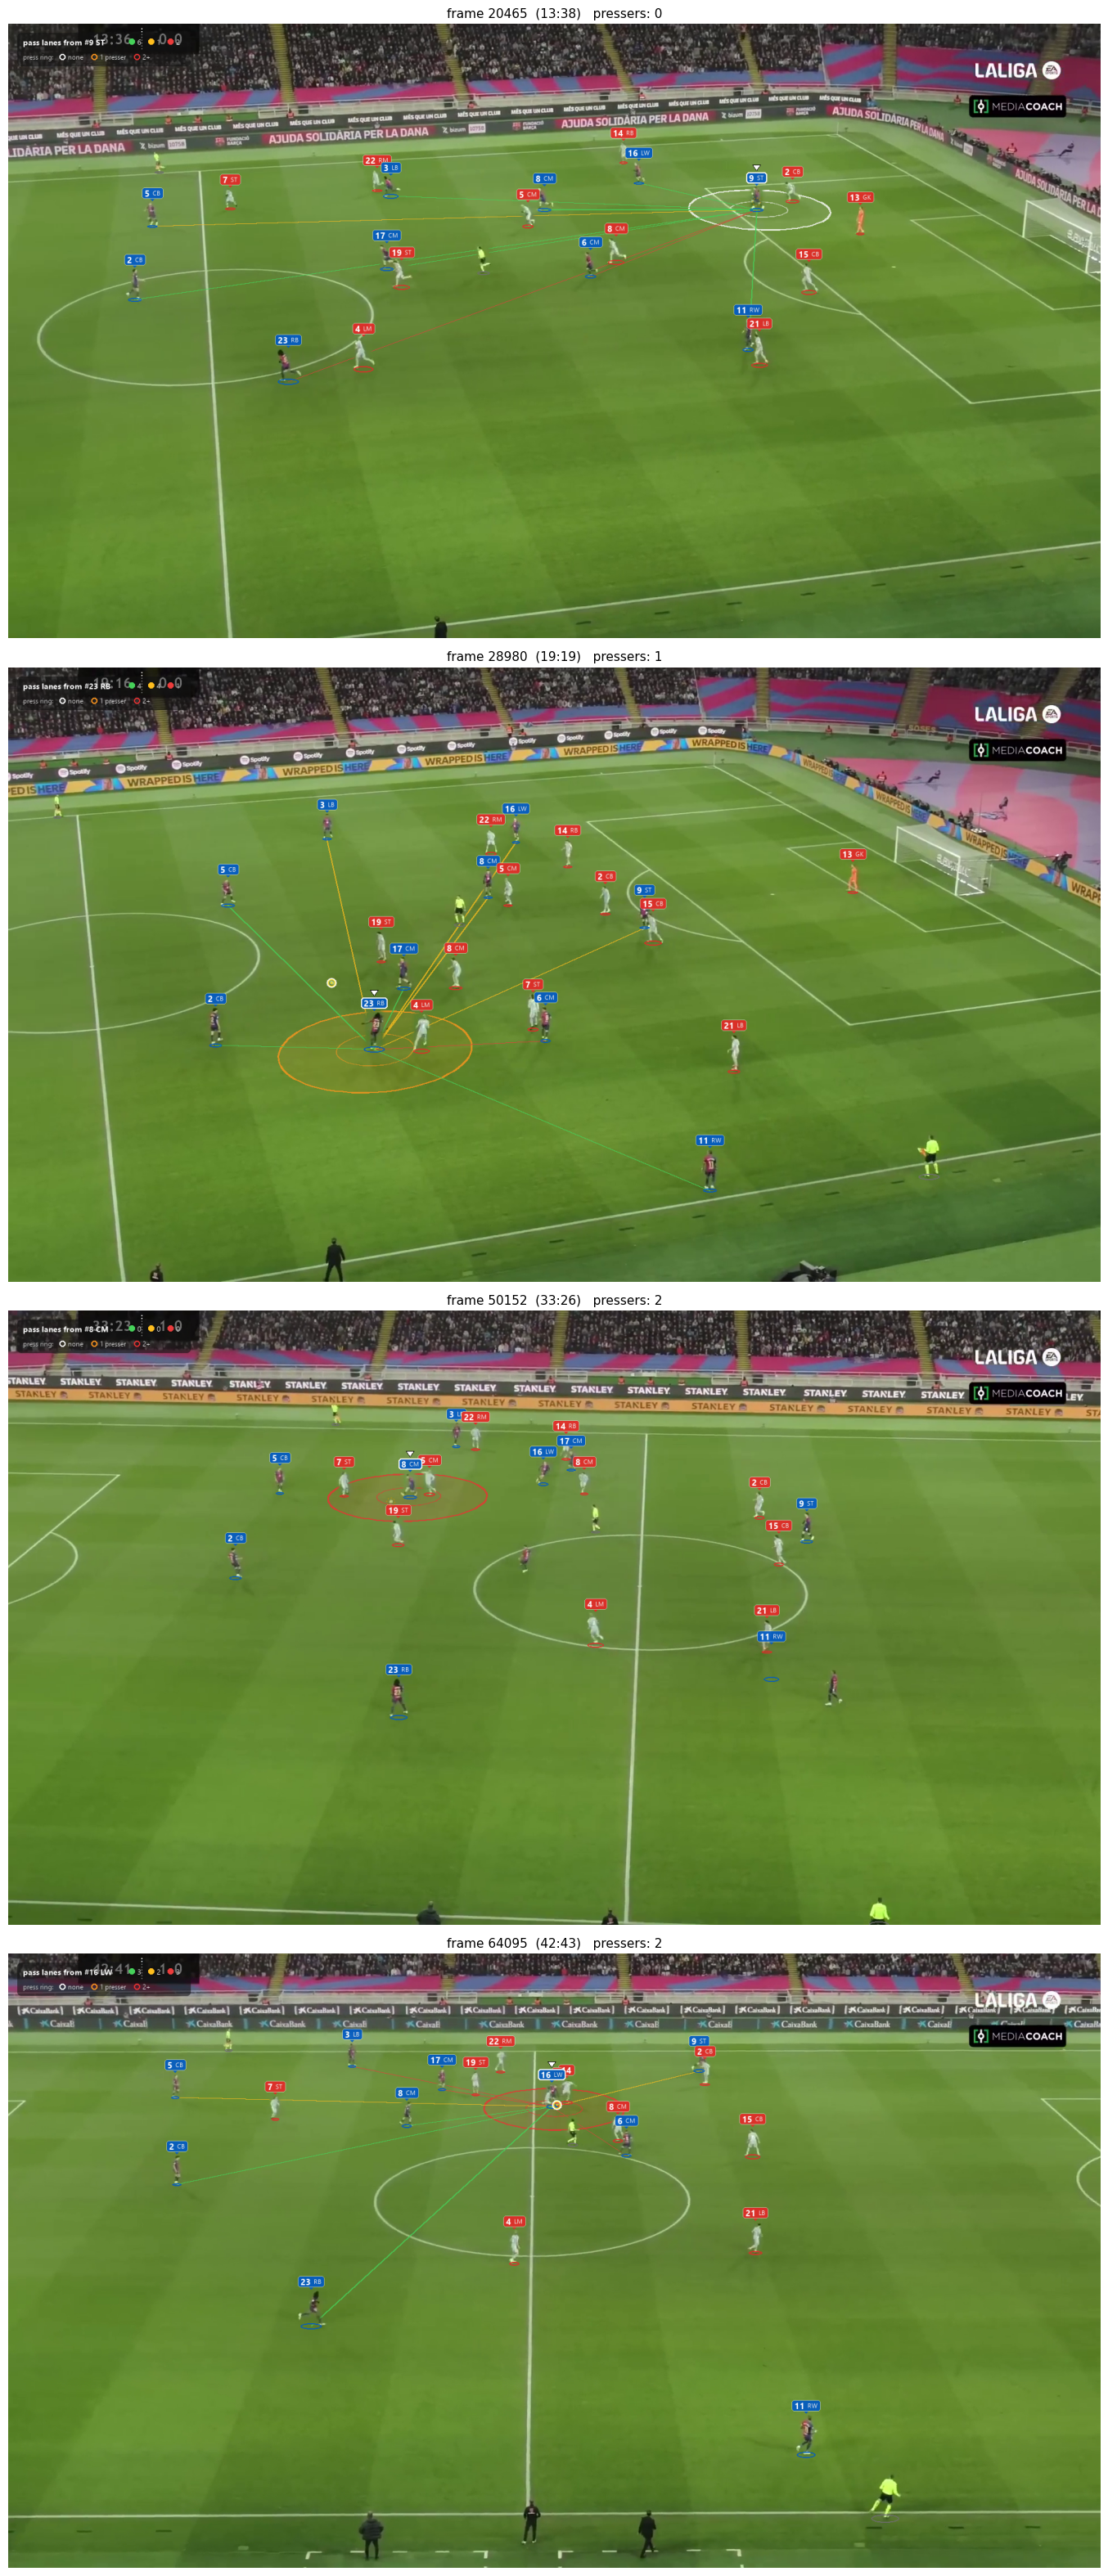

if the rings or lanes look shifted in time, change FRAME_OFFSET in cell 1; if they are missing, the camera fit failed in that frame (tags, ball and lanes still work).


In [4]:
# ================================================================== 4. Frame stream (one annotated frame at a time) + preview
# annotated_frames(f0, f1) is what the renderer uses; the preview below calls it for single frames, so what you check here is exactly what ends up in the video.
def annotated_frames(f0, f1):
    """Yields (frame_idx, annotated image) for the tracking frames f0..f1."""
    g0, g1 = max(0, f0 - EDGE_FRAMES), min(LAST_FRAME, f1 + EDGE_FRAMES); frames_all = np.arange(g0, g1 + 1)
    try:
        calib = pd.read_parquet(PLAYER_PATH, columns=CALIB_COLS, filters=[("frame_idx", ">=", g0), ("frame_idx", "<=", g1)])
    except Exception:
        calib = pd.read_parquet(PLAYER_PATH, columns=CALIB_COLS); calib = calib[(calib.frame_idx >= g0) & (calib.frame_idx <= g1)]
    if ALLOWED_PLAYER_SOURCES is not None:
        calib = calib[calib.source.isin(ALLOWED_PLAYER_SOURCES)]
    Hs = smooth_homographies(fit_homographies(calib), frames_all)         # fitted on the original pixels, then scaled with the picture
    K = float(OUT_SCALE)
    if K != 1.0:
        S_ = np.diag([K, K, 1.0]); Hs = {f: (None if H is None else S_ @ H) for f, H in Hs.items()}
        calib = calib.copy(); calib[PX_COLS] = calib[PX_COLS] * K
    boxes = smooth_boxes(calib)                                            # tags stay put: no jitter
    px_by_f = {k: g for k, g in boxes.groupby("frame_idx")}
    raw_by_f = {k: g for k, g in calib.groupby("frame_idx")}
    bpx = pd.read_parquet(BALL_PATH, columns=["frame_idx", "ball_px_x", "ball_px_y", "ball_source"])
    bpx = bpx[(bpx.frame_idx >= f0) & (bpx.frame_idx <= f1)].drop_duplicates("frame_idx").set_index("frame_idx")
    bpx[["ball_px_x", "ball_px_y"]] = bpx[["ball_px_x", "ball_px_y"]] * K
    pos_by_f = {k: g for k, g in player[(player.frame_idx >= g0) & (player.frame_idx <= g1)].groupby("frame_idx")}
    pr_win = pr_i.reindex(np.arange(f0, f1 + 1)); nprs = pr_win["n_pressing"].fillna(0).to_numpy(int); carriers = pr_win["carrier_track_id"].to_numpy(float)

    cap = cv2.VideoCapture(str(VIDEO_PATH)); cap.set(cv2.CAP_PROP_POS_FRAMES, f0 + FRAME_OFFSET)
    try:
        for i, f in enumerate(range(f0, f1 + 1)):
            ok_, img0 = cap.read()
            if not ok_:
                print(f"    video ended at frame {f - 1}"); return
            img = cv2.resize(img0, (int(round(img0.shape[1] * K)), int(round(img0.shape[0] * K))), interpolation=cv2.INTER_AREA) if K != 1.0 else img0
            brow = bpx.loc[f] if f in bpx.index else None
            carrier_id = int(carriers[i]) if not np.isnan(carriers[i]) else None            # the corrected carrier of the analysis (not the raw one)
            px_f = px_by_f.get(f)
            ball_xy = (brow.ball_px_x, brow.ball_px_y) if (brow is not None and pd.notna(brow.ball_px_x) and
                                                           (ALLOWED_BALL_SOURCES is None or brow.ball_source in ALLOWED_BALL_SOURCES)) else None
            ball_low = brow is not None and brow.ball_source in DASHED_FOR_SOURCES
            lane_info = None
            if px_f is not None:                                           # 1) ground graphics, behind the players
                foot = {int(r.track_id): (r.foot_px_x, r.foot_px_y) for r in px_f.itertuples() if pd.notna(r.foot_px_x)}
                pos_f = pos_by_f.get(f)
                lanes = compute_lanes(carrier_id, pos_f, foot) if (pos_f is not None and MATCH_LAYERS["pass_lanes"]) else []
                tgt = None
                if carrier_id is not None and f in raw_by_f:
                    cr = raw_by_f[f][raw_by_f[f].track_id == carrier_id]
                    if len(cr) and pd.notna(cr.iloc[0].pitch_x_raw):
                        tgt = (float(cr.iloc[0].pitch_x_raw), float(cr.iloc[0].pitch_y_raw))
                if tgt is None and f in pr_i.index and pd.notna(pr_i.at[f, "x"]):
                    tgt = (float(pr_i.at[f, "x"]), float(pr_i.at[f, "y"]))
                match_ground_layer(img, Hs.get(f), tgt, int(nprs[i]), lanes, px_f)
                if carrier_id is not None and MATCH_LAYERS["pass_lanes"]:
                    lane_info = dict(who=f"#{NUM_OF.get(carrier_id, '?')} {POS_OF.get(carrier_id, '')}", **{k: sum(1 for l in lanes if l[2] == k) for k in ("open", "contested", "blocked")})
                draw_base_layer(img, px_f, ball_xy, carrier_id, ball_low_conf=ball_low)   # 2) tags, carrier marker, ball
            elif ball_xy is not None:
                draw_ball(img, ball_xy, ball_low)
            draw_match_legend(img, lane_info)                              # 3) small legend (there is no header bar, nothing else)
            yield f, img
    finally:
        cap.release()

# ------------------------------------------------------------------ preview: single frames, before the long render
PREVIEW_TIMES = None         # None = pick 4 frames automatically (no pressure / 1 presser / 2+ pressers / a late one); or a list like ["12:30", "31:05"]
def _auto_times():
    ok = pr_i[pr_i.carrier_track_id.notna()]; picks = []
    for lo, hi, q in ((0, 0, 0.30), (1, 1, 0.45), (2, 9, 0.60), (2, 9, 0.90)):
        pool = ok[(ok.n_pressing >= lo) & (ok.n_pressing <= hi)]
        if len(pool):
            picks.append(int(pool.index[int(len(pool) * q)]))
    return picks
_frames = _auto_times() if PREVIEW_TIMES is None else [F(int(t.split(":")[0]) * 60 + int(t.split(":")[1])) for t in PREVIEW_TIMES]
fig, axes = plt.subplots(len(_frames), 1, figsize=(14, 7.9 * len(_frames)), squeeze=False)
for ax, f in zip(axes[:, 0], _frames):
    _, im = next(annotated_frames(f, f)); ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); ax.axis("off")
    n = int(pr_i.at[f, "n_pressing"]) if f in pr_i.index else 0
    ax.set_title(f"frame {f}  ({mmss(f)})   pressers: {n}", fontsize=11)
plt.tight_layout(); plt.show()
print("if the rings or lanes look shifted in time, change FRAME_OFFSET in cell 1; if they are missing, the camera fit failed in that frame (tags, ball and lanes still work).")


## 5. Render and join

In [5]:
# ================================================================== 5. Render the match (chunked, resumable) and join the chunks
def render_part(f0, f1, final_path):
    tmp_path = final_path.with_name("_rendering_" + final_path.name); vw = None; t0 = time.time(); n = f1 - f0 + 1
    for i, (f, img) in enumerate(annotated_frames(f0, f1)):
        if vw is None:
            for tag in (FULL_CODEC, "mp4v"):
                vw = cv2.VideoWriter(str(tmp_path), cv2.VideoWriter_fourcc(*tag), FPS, (img.shape[1], img.shape[0]))
                if vw.isOpened():
                    break
        vw.write(img)
        if (i + 1) % 1500 == 0:
            el = time.time() - t0; print(f"    {i + 1:,} / {n:,} frames  ({(i + 1) / el:.1f} frames/s, about {(n - i - 1) / ((i + 1) / el) / 60:.1f} min left in this chunk)")
    assert vw is not None, f"no frames could be read for {f0} - {f1}"
    vw.release()
    os.replace(tmp_path, final_path)                                       # only a finished chunk gets its real name, so a crash never leaves a half file that looks complete
    return final_path

def join_parts(paths, out_path):
    ff = shutil.which("ffmpeg")
    if ff:
        lst = FULL_DIR / "_parts.txt"; lst.write_text("".join(f"file '{p.as_posix()}'\n" for p in paths), encoding="utf-8")
        r = subprocess.run([ff, "-y", "-loglevel", "error", "-f", "concat", "-safe", "0", "-i", str(lst), "-c", "copy", str(out_path)])
        if r.returncode == 0 and out_path.exists():
            return "ffmpeg (no re-encoding)"
    c0 = cv2.VideoCapture(str(paths[0])); W_, H_ = int(c0.get(cv2.CAP_PROP_FRAME_WIDTH)), int(c0.get(cv2.CAP_PROP_FRAME_HEIGHT)); c0.release()
    vw = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*FULL_CODEC), FPS, (W_, H_))
    for p in paths:
        c = cv2.VideoCapture(str(p))
        while True:
            ok_, im = c.read()
            if not ok_:
                break
            vw.write(im)
        c.release()
    vw.release()
    return "OpenCV (re-encoded)"

f_start, f_end = (0, LAST_FRAME) if RANGE_MIN is None else (F(RANGE_MIN[0] * 60), min(LAST_FRAME, F(RANGE_MIN[1] * 60)))
step = F(CHUNK_SEC)
plan = [(a, min(a + step - 1, f_end)) for a in range(f_start, f_end + 1, step)]
tag = "" if RANGE_MIN is None else f"_{RANGE_MIN[0]:g}-{RANGE_MIN[1]:g}min"
part_path = lambda k, a, b: FULL_DIR / f"{FULL_NAME}{tag}_part{k:02d}_{a:06d}-{b:06d}.mp4"
print(f"frames {f_start:,} - {f_end:,} ({(f_end - f_start + 1) / FPS / 60:.1f} min) in {len(plan)} chunk(s) of {CHUNK_SEC} s | output scale {OUT_SCALE} | folder {FULL_DIR}")
t_all = time.time(); parts = []
for k, (a, b) in enumerate(plan, 1):
    p = part_path(k, a, b); parts.append(p)
    if p.exists() and p.stat().st_size > 0 and not FULL_OVERWRITE:
        print(f"[{k}/{len(plan)}] skipped (already rendered) {p.name}"); continue
    t0 = time.time(); print(f"[{k}/{len(plan)}] rendering {mmss(a)} - {mmss(b)}  (frames {a:,} - {b:,})")
    render_part(a, b, p)
    print(f"[{k}/{len(plan)}] done: {p.name}  ({p.stat().st_size / 1e6:.0f} MB, {(time.time() - t0) / 60:.1f} min, {(time.time() - t_all) / 60:.1f} min in total)")
if JOIN and all(p.exists() for p in parts):
    out = FULL_DIR / f"{FULL_NAME}{tag}.mp4"
    how = join_parts(parts, out) if len(parts) > 1 else (shutil.copyfile(parts[0], out) and "single chunk")
    print(f"\nFULL VIDEO: {out}  ({out.stat().st_size / 1e6:.0f} MB, joined with {how})")
else:
    print("\nchunks are in", FULL_DIR)


frames 0 - 70,043 (46.7 min) in 10 chunk(s) of 300 s | output scale 1.0 | folder C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\buildup_output\full_match
[1/10] rendering 00:00 - 04:59  (frames 0 - 7,499)
    1,500 / 7,500 frames  (7.6 frames/s, about 13.1 min left in this chunk)
    3,000 / 7,500 frames  (7.9 frames/s, about 9.6 min left in this chunk)
    4,500 / 7,500 frames  (8.0 frames/s, about 6.3 min left in this chunk)
    6,000 / 7,500 frames  (7.9 frames/s, about 3.2 min left in this chunk)
    7,500 / 7,500 frames  (7.8 frames/s, about 0.0 min left in this chunk)
[1/10] done: full_match_first_half_part01_000000-007499.mp4  (343 MB, 16.0 min, 16.0 min in total)
[2/10] rendering 05:00 - 09:59  (frames 7,500 - 14,999)
    1,500 / 7,500 frames  (7.8 frames/s, about 12.8 min left in this chunk)
    3,000 / 7,500 frames  (8.0 frames/s, about 9.4 min left in this chunk)
    4,500 / 7,500 frames  (8.1 frames/s, about 6.2 min left in this chunk)
   